# Resumen — Tipos de Variables y Tendencia Central

> **Para el TP1 de Estadística Descriptiva I**  
> Usá este cuaderno para repasar los conceptos antes de rendir o para consulta rápida.


---
## 1. Tipos de Variables

Clasificar variables es el primer paso de cualquier análisis. Determina qué operaciones estadísticas tienen sentido.

| Tipo principal | Subtipo | Descripción | Ejemplo |
|---|---|---|---|
| **Cualitativa (Categórica)** | **Nominal** | Sin orden entre categorías | País, color, departamento |
| **Cualitativa (Categórica)** | **Ordinal** | Con orden natural entre categorías | Nivel educativo, satisfacción |
| **Cuantitativa (Numérica)** | **Discreta** | Solo valores enteros (conteos) | Hijos, productos vendidos |
| **Cuantitativa (Numérica)** | **Continua** | Cualquier valor en un rango | Salario, temperatura, edad |

**Regla clave:** La media solo tiene sentido en variables cuantitativas. La moda aplica a todas. La mediana aplica a ordinales y cuantitativas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset de ejemplo
data = {
    'nombre':          ['Ana', 'Bruno', 'Carla', 'Diego', 'Elena',
                        'Franco', 'Gaby', 'Héctor', 'Irene', 'Jorge'],
    'edad':            [25, 31, 28, 45, 33, 29, 27, 52, 30, 38],
    'salario':         [45000, 62000, 58000, 75000, 68000, 51000, 49000, 320000, 63000, 71000],
    'hijos':           [0, 1, 0, 2, 1, 0, 3, 2, 1, 0],
    'nivel_educativo': ['Secundario', 'Universitario', 'Universitario', 'Posgrado',
                        'Universitario', 'Secundario', 'Terciario', 'Posgrado',
                        'Universitario', 'Universitario'],
    'satisfaccion':    ['Alta', 'Media', 'Alta', 'Baja', 'Alta',
                        'Media', 'Alta', 'Baja', 'Media', 'Alta'],
    'departamento':    ['Ventas', 'IT', 'IT', 'RRHH', 'Ventas',
                        'IT', 'RRHH', 'Dirección', 'Ventas', 'IT']
}
df = pd.DataFrame(data)
print('dtypes:')
print(df.dtypes)


dtypes:
nombre               str
edad               int64
salario            int64
hijos              int64
nivel_educativo      str
satisfaccion         str
departamento         str
dtype: object


### 1.1 Convertir variable ordinal a Categorical

Pandas no sabe que 'satisfaccion' tiene orden — hay que decírselo explícitamente.


In [2]:
# Definimos el orden correcto
df['satisfaccion'] = pd.Categorical(
    df['satisfaccion'],
    categories=['Baja', 'Media', 'Alta'],
    ordered=True
)

print('Tipo:', df['satisfaccion'].dtype)
print('Ordenada:', df['satisfaccion'].cat.ordered)
print('Orden:', df['satisfaccion'].cat.categories.tolist())
print()
# Ahora podemos comparar directamente
print('¿Alta > Baja?:', df['satisfaccion'][0] > df['satisfaccion'][3])


Tipo: category
Ordenada: True
Orden: ['Baja', 'Media', 'Alta']

¿Alta > Baja?: False


---
## 2. Medidas de Tendencia Central

Responden a: **¿dónde se concentran los datos?**

| Medida | Fórmula / idea | Cuándo usarla | Robustez ante outliers |
|---|---|---|---|
| **Media** | suma / n | Variables cuantitativas sin outliers | Baja — la afectan mucho |
| **Mediana** | valor del medio (ordenados) | Cuantitativas con outliers | Alta — no la afectan |
| **Moda** | valor más frecuente | Todas las variables | Alta |


In [3]:
import statistics

print('=== EDAD ===')
print(f'  Media   : {df["edad"].mean():.2f}')
print(f'  Mediana : {df["edad"].median():.2f}')
print(f'  Moda    : {statistics.mode(df["edad"])}')

print('\n=== SALARIO (con outlier: Héctor=$320.000) ===')
print(f'  Media   : {df["salario"].mean():,.2f}')
print(f'  Mediana : {df["salario"].median():,.2f}')
print(f'  Moda    : {df["salario"].mode().values}')

print('\n=> La diferencia Media vs Mediana en SALARIO delata el outlier de Héctor.')


=== EDAD ===
  Media   : 33.80
  Mediana : 30.50
  Moda    : 25

=== SALARIO (con outlier: Héctor=$320.000) ===
  Media   : 86,200.00
  Mediana : 62,500.00
  Moda    : [ 45000  49000  51000  58000  62000  63000  68000  71000  75000 320000]

=> La diferencia Media vs Mediana en SALARIO delata el outlier de Héctor.


### 2.1 Visualizar el efecto del outlier


C:\Users\david\AppData\Local\Temp\ipykernel_20132\297870898.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(df['nombre'], rotation=45, ha='right')
C:\Users\david\AppData\Local\Temp\ipykernel_20132\297870898.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(df['nombre'], rotation=45, ha='right')


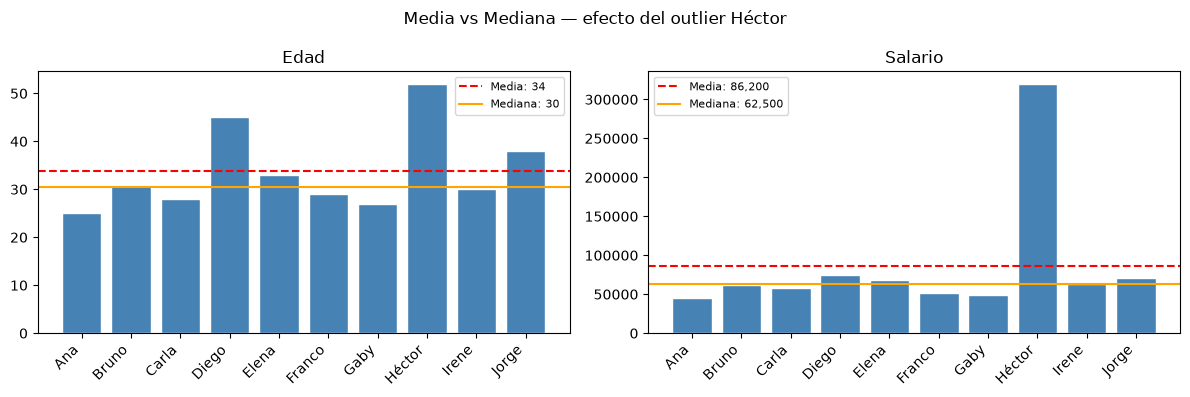

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['edad', 'salario']):
    ax.bar(df['nombre'], df[col], color='steelblue', edgecolor='white')
    ax.axhline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5,
               label=f'Media: {df[col].mean():,.0f}')
    ax.axhline(df[col].median(), color='orange', linestyle='-',  linewidth=1.5,
               label=f'Mediana: {df[col].median():,.0f}')
    ax.set_title(col.capitalize())
    ax.set_xticklabels(df['nombre'], rotation=45, ha='right')
    ax.legend(fontsize=8)

plt.suptitle('Media vs Mediana — efecto del outlier Héctor')
plt.tight_layout()
plt.show()


### 2.2 Moda en variables categóricas

Para variables **nominales** (departamento), solo la moda es válida.  
Para variables **ordinales** (nivel_educativo), moda **y** mediana son válidas.


In [5]:
print('Moda de departamento    :', df['departamento'].mode().values)
print('Moda de nivel_educativo :', df['nivel_educativo'].mode().values)


Moda de departamento    : <StringArray>
['IT']
Length: 1, dtype: str
Moda de nivel_educativo : <StringArray>
['Universitario']
Length: 1, dtype: str


---
## 3. Percentiles y Cuartiles

Los percentiles dividen la distribución ordenada en 100 partes iguales.
Los **cuartiles** son los percentiles 25, 50 y 75.

| Notación | Percentil | Significado |
|---|---|---|
| Q1 | P25 | El 25% de los datos está por debajo de este valor |
| Q2 (Mediana) | P50 | El 50% está por debajo |
| Q3 | P75 | El 75% está por debajo |
| IQR | Q3 - Q1 | Rango intercuartílico — el 50% central de los datos |


In [6]:
percentiles = df['salario'].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
print('Percentiles de salario:')
for p, v in percentiles.items():
    print(f'  P{int(p*100):2d}: {v:>10,.0f}')

print(f'\nIQR (Q3 - Q1) = {percentiles[0.75] - percentiles[0.25]:,.0f}')


Percentiles de salario:
  P10:     48,600
  P25:     52,750
  P50:     62,500
  P75:     70,250
  P90:     99,500

IQR (Q3 - Q1) = 17,500


### 3.1 Comparar con y sin outlier


In [7]:
df_sin = df[df['nombre'] != 'Héctor']

print(f"{'':20s} {'CON Héctor':>12s} {'SIN Héctor':>12s}")
print(f"{'Media':20s} {df['salario'].mean():>12,.0f} {df_sin['salario'].mean():>12,.0f}")
print(f"{'Mediana':20s} {df['salario'].median():>12,.0f} {df_sin['salario'].median():>12,.0f}")
print()
print('=> La mediana cambió poco; la media cambió drásticamente. Por eso la mediana')
print('   es más robusta ante outliers y representa mejor el salario típico.')


                       CON Héctor   SIN Héctor
Media                      86,200       60,222
Mediana                    62,500       62,000

=> La mediana cambió poco; la media cambió drásticamente. Por eso la mediana
   es más robusta ante outliers y representa mejor el salario típico.


---
## 4. Resumen de reglas para elegir la medida correcta

| Variable | Medida recomendada | Motivo |
|---|---|---|
| Nominal sin outliers | Moda | Sin orden ni aritmética posible |
| Ordinal | Mediana o Moda | Hay orden pero no intervalos iguales |
| Cuantitativa sin outliers | Media | Usa toda la información |
| Cuantitativa con outliers | Mediana | No se distorsiona por extremos |

> **Tip de examen:** si media ≠ mediana, es señal de asimetría (sesgo) o outliers.
